In [1]:
import time
import tracemalloc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx

from simpleai.search import SearchProblem, breadth_first, depth_first, astar

print("Librerias cargadas correctamente")

Librerias cargadas correctamente


In [2]:
maze = np.array([
    [0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 0, 0, 1, 0]
])

start = (0, 0)
goal = (9, 9)

print("Tamano del laberinto:", maze.shape)
print("Entrada:", start)
print("Salida:", goal)

Tamano del laberinto: (10, 10)
Entrada: (0, 0)
Salida: (9, 9)


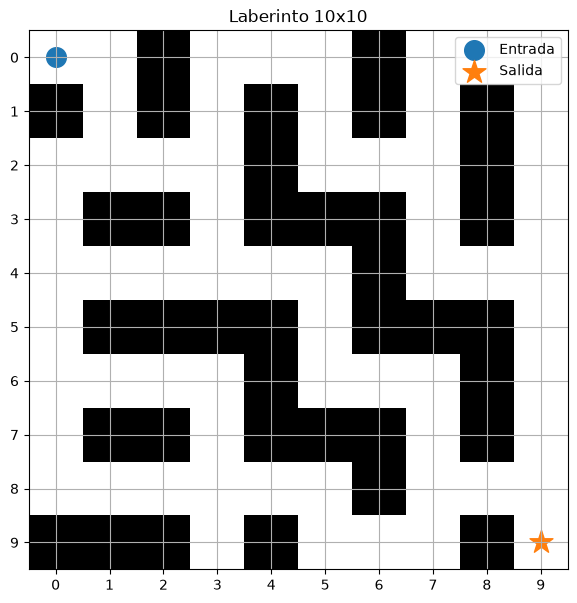

In [3]:
def draw_maze(maze, start, goal, path=None, title="Laberinto"):
    plt.figure(figsize=(7, 7))
    plt.imshow(maze, cmap="gray_r")
    plt.scatter(start[1], start[0], marker="o", s=200, label="Entrada")
    plt.scatter(goal[1], goal[0], marker="*", s=300, label="Salida")

    if path:
        y = [p[0] for p in path]
        x = [p[1] for p in path]
        plt.plot(x, y, linewidth=4, label="Solucion")

    plt.xticks(range(maze.shape[1]))
    plt.yticks(range(maze.shape[0]))
    plt.grid(True)
    plt.title(title)
    plt.legend()
    plt.show()

draw_maze(maze, start, goal, title="Laberinto 10x10")

In [4]:
class MazeProblem(SearchProblem):
    def __init__(self, maze, start, goal):
        self.maze = maze
        self.goal = goal
        self.nodes_visited = 0
        super().__init__(initial_state=start)

    def actions(self, state):
        self.nodes_visited += 1
        row, col = state

        moves = {
            "Arriba": (-1, 0),
            "Abajo": (1, 0),
            "Izquierda": (0, -1),
            "Derecha": (0, 1)
        }

        result = []

        for action, (dr, dc) in moves.items():
            nr = row + dr
            nc = col + dc

            if 0 <= nr < self.maze.shape[0] and 0 <= nc < self.maze.shape[1]:
                if self.maze[nr, nc] == 0:
                    result.append(action)

        return result

    def result(self, state, action):
        row, col = state

        moves = {
            "Arriba": (-1, 0),
            "Abajo": (1, 0),
            "Izquierda": (0, -1),
            "Derecha": (0, 1)
        }

        dr, dc = moves[action]
        return row + dr, col + dc

    def is_goal(self, state):
        return state == self.goal

    def cost(self, state, action, state2):
        return 1

    def heuristic(self, state):
        return abs(state[0] - self.goal[0]) + abs(state[1] - self.goal[1])

In [5]:
def solution_to_path(solution):
    return [state for action, state in solution]

In [6]:
def run_search(search_function, graph_search=True):
    problem = MazeProblem(maze, start, goal)

    tracemalloc.start()
    t0 = time.perf_counter()

    solution = search_function(problem, graph_search=graph_search)

    elapsed = time.perf_counter() - t0
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    path = solution_to_path(solution.path())

    return {
        "solution": solution,
        "path": path,
        "nodes": problem.nodes_visited,
        "time": elapsed,
        "memory": peak / 1024
    }

In [7]:
result_bfs = run_search(breadth_first, True)

print("BFS")
print("Nodos visitados:", result_bfs["nodes"])
print("Tiempo:", result_bfs["time"])
print("Memoria:", result_bfs["memory"])
print("Longitud del camino:", len(result_bfs["path"]))

BFS
Nodos visitados: 60
Tiempo: 0.0024736979999602227
Memoria: 11.765625
Longitud del camino: 19


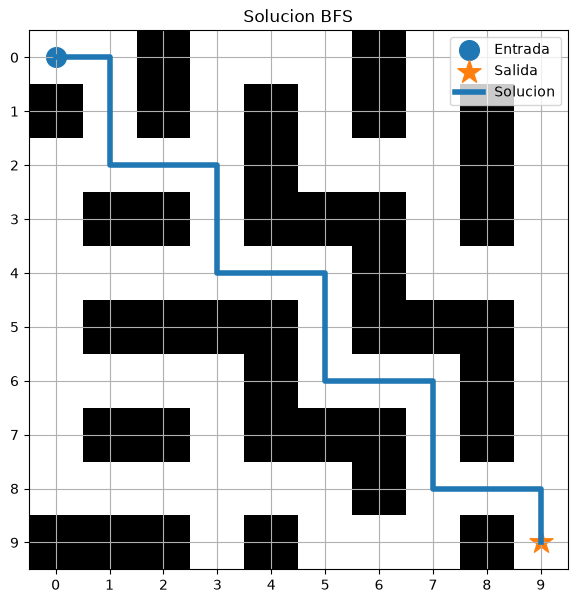

In [8]:
draw_maze(
    maze,
    start,
    goal,
    result_bfs["path"],
    "Solucion BFS"
)

In [9]:
result_dfs = run_search(depth_first, True)

print("DFS")
print("Nodos visitados:", result_dfs["nodes"])
print("Tiempo:", result_dfs["time"])
print("Memoria:", result_dfs["memory"])
print("Longitud del camino:", len(result_dfs["path"]))

DFS
Nodos visitados: 18
Tiempo: 0.0008362759999727132
Memoria: 5.1484375
Longitud del camino: 19


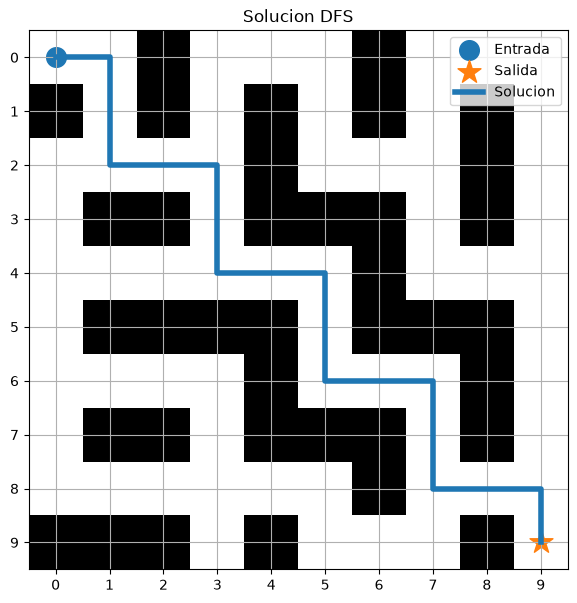

In [10]:
draw_maze(
    maze,
    start,
    goal,
    result_dfs["path"],
    "Solucion DFS"
)

In [11]:
result_astar = run_search(astar, True)

print("A*")
print("Nodos visitados:", result_astar["nodes"])
print("Tiempo:", result_astar["time"])
print("Memoria:", result_astar["memory"])
print("Longitud del camino:", len(result_astar["path"]))

A*
Nodos visitados: 19
Tiempo: 0.0016722029999982624
Memoria: 8.75
Longitud del camino: 19


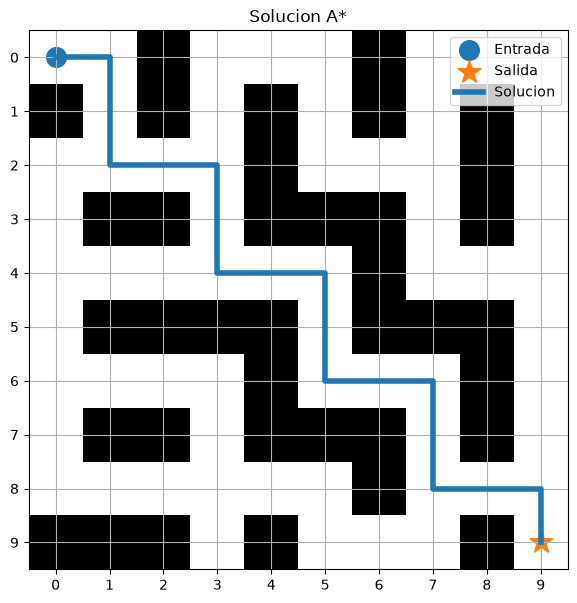

In [12]:
draw_maze(
    maze,
    start,
    goal,
    result_astar["path"],
    "Solucion A*"
)

In [13]:
def maze_to_graph(maze):
    graph = nx.Graph()

    for r in range(maze.shape[0]):
        for c in range(maze.shape[1]):
            if maze[r, c] == 0:
                graph.add_node((r, c))

                for nr, nc in [
                    (r - 1, c),
                    (r + 1, c),
                    (r, c - 1),
                    (r, c + 1)
                ]:
                    if 0 <= nr < maze.shape[0] and 0 <= nc < maze.shape[1]:
                        if maze[nr, nc] == 0:
                            graph.add_edge((r, c), (nr, nc), weight=1)

    return graph

graph = maze_to_graph(maze)

important = {
    node for node in graph.nodes
    if graph.degree[node] != 2
}

important.add(start)
important.add(goal)

topological_graph = nx.Graph()
topological_graph.add_nodes_from(important)

for node in important:
    for neighbor in graph.neighbors(node):
        if node > neighbor:
            continue

        previous = node
        current = neighbor
        distance = 1

        while current not in important:
            next_nodes = [x for x in graph.neighbors(current) if x != previous]
            previous, current = current, next_nodes[0]
            distance += 1

        topological_graph.add_edge(
            node,
            current,
            weight=distance
        )

print("Nodos originales:", len(graph.nodes))
print("Nodos topologicos:", len(topological_graph.nodes))

Nodos originales: 63
Nodos topologicos: 13


In [14]:
def topological_heuristic(node):
    return abs(node[0] - goal[0]) + abs(node[1] - goal[1])

def astar_topological(graph, start, goal):
    import heapq

    queue = []
    heapq.heappush(queue, (topological_heuristic(start), 0, start))

    parent = {start: None}
    cost = {start: 0}
    visited = set()
    nodes = 0

    while queue:
        _, current_cost, current = heapq.heappop(queue)

        if current in visited:
            continue

        visited.add(current)
        nodes += 1

        if current == goal:
            break

        for neighbor in graph.neighbors(current):
            weight = graph[current][neighbor]["weight"]
            new_cost = current_cost + weight

            if neighbor not in cost or new_cost < cost[neighbor]:
                cost[neighbor] = new_cost
                parent[neighbor] = current
                priority = new_cost + topological_heuristic(neighbor)
                heapq.heappush(queue, (priority, new_cost, neighbor))

    important_path = []
    current = goal

    if current not in parent:
        return None, nodes

    while current is not None:
        important_path.append(current)
        current = parent[current]

    important_path.reverse()

    full_path = [important_path[0]]

    for i in range(len(important_path) - 1):
        a = important_path[i]
        b = important_path[i + 1]

        current = a
        previous = None

        while current != b:
            neighbors = list(graph.neighbors(current))
            candidates = [x for x in neighbors if x != previous]

            if b in candidates:
                next_node = b
            else:
                next_node = candidates[0]

            previous, current = current, next_node
            full_path.append(current)

    return full_path, nodes

In [15]:
tracemalloc.start()
t0 = time.perf_counter()

path_topological, nodes_topological = astar_topological(
    topological_graph,
    start,
    goal
)

elapsed_topological = time.perf_counter() - t0
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

memory_topological = peak / 1024

result_topological = {
    "path": path_topological,
    "nodes": nodes_topological,
    "time": elapsed_topological,
    "memory": memory_topological
}

print("A* Topologico")
print("Nodos visitados:", result_topological["nodes"])
print("Tiempo:", result_topological["time"])
print("Memoria:", result_topological["memory"])
print("Longitud del camino:", len(result_topological["path"]))

A* Topologico
Nodos visitados: 7
Tiempo: 0.0004916099999832113
Memoria: 20.9482421875
Longitud del camino: 7


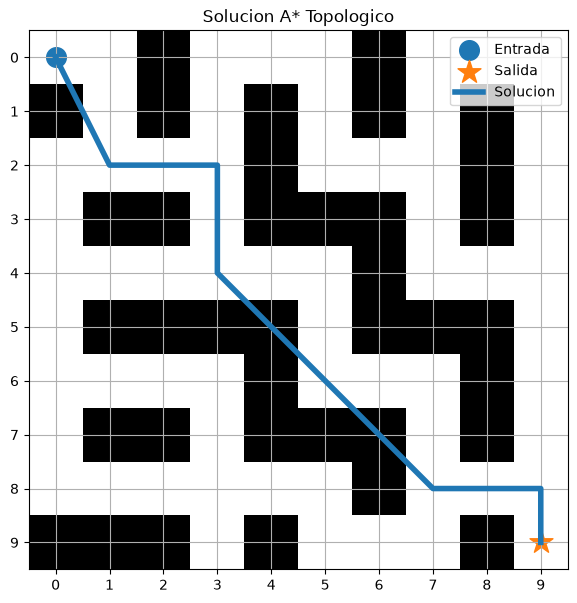

In [16]:
draw_maze(
    maze,
    start,
    goal,
    result_topological["path"],
    "Solucion A* Topologico"
)

In [17]:
results = pd.DataFrame([
    {
        "Algoritmo": "BFS",
        "Nodos visitados": result_bfs["nodes"],
        "Tiempo": result_bfs["time"],
        "Memoria KB": result_bfs["memory"],
        "Longitud camino": len(result_bfs["path"])
    },
    {
        "Algoritmo": "DFS",
        "Nodos visitados": result_dfs["nodes"],
        "Tiempo": result_dfs["time"],
        "Memoria KB": result_dfs["memory"],
        "Longitud camino": len(result_dfs["path"])
    },
    {
        "Algoritmo": "A*",
        "Nodos visitados": result_astar["nodes"],
        "Tiempo": result_astar["time"],
        "Memoria KB": result_astar["memory"],
        "Longitud camino": len(result_astar["path"])
    },
    {
        "Algoritmo": "A* Topologico",
        "Nodos visitados": result_topological["nodes"],
        "Tiempo": result_topological["time"],
        "Memoria KB": result_topological["memory"],
        "Longitud camino": len(result_topological["path"])
    }
])

results

,Algoritmo,Nodos visitados,Tiempo,Memoria KB,Longitud camino
0,BFS,60,0.002474,11.765625,19
1,DFS,18,0.000836,5.148438,19
2,A*,19,0.001672,8.750000,19
3,A* Topologico,7,0.000492,20.948242,7


In [18]:
print(results.to_string(index=False))

    Algoritmo  Nodos visitados   Tiempo  Memoria KB  Longitud camino
          BFS               60 0.002474   11.765625               19
          DFS               18 0.000836    5.148438               19
           A*               19 0.001672    8.750000               19
A* Topologico                7 0.000492   20.948242                7


In [19]:
print("Comparacion terminada")
print("BFS:", len(result_bfs["path"]))
print("DFS:", len(result_dfs["path"]))
print("A*:", len(result_astar["path"]))
print("A* Topologico:", len(result_topological["path"]))

Comparacion terminada
BFS: 19
DFS: 19
A*: 19
A* Topologico: 7
